## At a glance

In [1]:
#| echo: false
#| output: false
#| eval: true

import json
from IPython.display import HTML
from pathlib import Path
from urllib.parse import quote
import requests
import pandas as pd
import plotly.graph_objects as go
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from wordcloud import WordCloud

CITING_REFS_PATH = Path("../files/references_citing_us.csv")
OPENALEX_USER_AGENT = "CARD Lab scientometrics (mailto:paytonej@ucmail.uc.edu)"
EXCLUDED_AFFILIATION_TOKEN = "university of cincinnati"
ZOTERO_GROUP_ID = 2262968
CARD_LAB_START_DATE = pd.Timestamp("2012-01-01")
REQUEST_DELAY_SECONDS = 0.5
TOP_N_JOURNALS = 15

STOPWORDS = {
    "a", "an", "and", "as", "at", "but", "by", "for", "from", "has", "he", "in", "into", 
    "is", "it", "its", "of", "on", "or", "she", "that", "the", "to", "was", "will", "with",
    "study", "studies", "effect", "effects", "analysis", "research", "method", "methods",
    "new", "novel", "high", "low", "different", "various", "number", "time", "based",
    "data", "model", "modeling", "models", "approach", "approaches", "results", "result",
    "observations", "observation", "findings", "finding", "systems", "system", "material",
    "materials", "used", "using", "found", "show", "shows", "present", "investigate",
    "investigation", "develop", "development", "understand", "understanding", "improve",
    "improvement", "enhance", "enhancement", "increase", "increase", "decrease", "decrease",
}

REFERENCE_COLUMNS = ["doi", "title", "abstract", "keywords", "journal_name", "affiliations"]


def make_value_box(title, value, icon_name, theme, decimals=1):
    """Return HTML for a value box with an icon."""
    return f"""
    <div class="value-box {theme}">
      <div class="top-row">
        <div class="label">{title}</div>
        <iconify-icon icon="{icon_name}"></iconify-icon>
      </div>
      <div class="value">{value:.{decimals}f}</div>
    </div>
    """


def _normalize_doi(value):
    if pd.isna(value):
        return None
    doi = str(value).strip().lower()
    doi = doi.replace("https://doi.org/", "").replace("http://doi.org/", "")
    doi = doi.replace("doi:", "")
    return doi or None


def _normalize_work_id(value):
    text = str(value or "").strip().lower()
    return text or None


def _split_semicolon_values(series):
    values = set()
    for item in series.fillna("").astype(str):
        for part in item.split(";"):
            cleaned = part.strip()
            if cleaned:
                values.add(cleaned)
    return values


def _decode_openalex_abstract(abstract_index):
    if not isinstance(abstract_index, dict) or not abstract_index:
        return ""
    max_pos = -1
    for positions in abstract_index.values():
        if isinstance(positions, list) and positions:
            max_pos = max(max_pos, max(positions))
    if max_pos < 0:
        return ""
    tokens = [""] * (max_pos + 1)
    for word, positions in abstract_index.items():
        if not isinstance(positions, list):
            continue
        for pos in positions:
            if isinstance(pos, int) and 0 <= pos <= max_pos:
                tokens[pos] = str(word)
    return " ".join(token for token in tokens if token).strip()


def _fetch_openalex_work_metadata(doi, session):
    work_url = f"https://api.openalex.org/works/https://doi.org/{quote(doi, safe='')}"
    try:
        response = session.get(
            work_url,
            headers={"User-Agent": OPENALEX_USER_AGENT},
            timeout=20,
        )
        response.raise_for_status()
        work = response.json()
    except Exception as exc:
        print(f"Warning: unable to fetch OpenAlex metadata for {doi}: {exc}")
        return {
            "doi": doi,
            "title": "",
            "abstract": "",
            "keywords": "",
            "journal_name": "",
            "affiliations": "",
        }

    keywords = []
    for kw in work.get("keywords", []) or []:
        if isinstance(kw, dict):
            name = str(kw.get("display_name") or "").strip()
        else:
            name = str(kw).strip()
        if name:
            keywords.append(name)

    if not keywords:
        for concept in work.get("concepts", []) or []:
            if not isinstance(concept, dict):
                continue
            if float(concept.get("score") or 0.0) < 0.3:
                continue
            name = str(concept.get("display_name") or "").strip()
            if name:
                keywords.append(name)

    affiliations = []
    for authorship in work.get("authorships", []) or []:
        institutions = authorship.get("institutions", []) or []
        if institutions:
            for institution in institutions:
                name = str(institution.get("display_name") or "").strip()
                if name:
                    affiliations.append(name)
        else:
            raw_affiliation = str(authorship.get("raw_affiliation_string") or "").strip()
            if raw_affiliation:
                affiliations.append(raw_affiliation)

    journal_name = str(
        (((work.get("primary_location") or {}).get("source") or {}).get("display_name")) or ""
    ).strip()

    return {
        "doi": doi,
        "title": str(work.get("title") or "").strip(),
        "abstract": _decode_openalex_abstract(work.get("abstract_inverted_index")),
        "keywords": "; ".join(dict.fromkeys(keywords)),
        "journal_name": journal_name,
        "affiliations": "; ".join(dict.fromkeys(affiliations)),
    }


unique_journal_citations = 0
h_index_like = 0
unique_author_affiliations = 0
journals_citing_card_lab = 0

if not CITING_REFS_PATH.exists():
    print(f"Warning: {CITING_REFS_PATH} not found.")
else:
    df_citing_refs = pd.read_csv(CITING_REFS_PATH)

    if "citing_doi" in df_citing_refs.columns:
        df_citing_refs["citing_doi_norm"] = df_citing_refs["citing_doi"].map(_normalize_doi)
        unique_citing_dois = sorted(
            doi for doi in df_citing_refs["citing_doi_norm"].dropna().unique().tolist() if doi
        )
        unique_journal_citations = len(unique_citing_dois)
    else:
        unique_citing_dois = []

    if unique_citing_dois:
        work_ids = pd.Series(pd.NA, index=df_citing_refs.index, dtype="object")
        for col in ["ref_doi", "ref_key", "ref_title"]:
            if col in df_citing_refs.columns:
                normalized = df_citing_refs[col].map(_normalize_work_id)
                work_ids = work_ids.fillna(normalized)
        df_citing_refs["referenced_work_id"] = work_ids

        citation_counts = (
            df_citing_refs.dropna(subset=["citing_doi_norm", "referenced_work_id"])
            .groupby("referenced_work_id")["citing_doi_norm"]
            .nunique()
            .sort_values(ascending=False)
            .tolist()
        )

        h_index_like = max(
            (rank for rank, count in enumerate(citation_counts, start=1) if count >= rank),
            default=0,
        )

        # Check if metadata columns are already in the main CSV
        metadata_cols = ["title", "abstract", "keywords", "journal_name", "affiliations"]
        missing_metadata = []
        
        for col in metadata_cols:
            if col not in df_citing_refs.columns:
                missing_metadata.append(col)

        # If any metadata columns are missing or mostly empty, fetch from OpenAlex
        if missing_metadata:
            print(f"Adding missing metadata columns: {missing_metadata}")
            for col in missing_metadata:
                df_citing_refs[col] = ""

            pending_dois = []
            for doi in unique_citing_dois:
                has_metadata = False
                for col in ["title", "journal_name", "affiliations"]:
                    if col in df_citing_refs.columns and str(df_citing_refs[df_citing_refs["citing_doi_norm"] == doi][col].iloc[0] if len(df_citing_refs[df_citing_refs["citing_doi_norm"] == doi]) > 0 else "").strip():
                        has_metadata = True
                        break
                if not has_metadata:
                    pending_dois.append(doi)

            if pending_dois:
                print(f"Fetching missing metadata for {len(pending_dois)} citing DOI(s)...")
                session = requests.Session()
                new_rows = []
                for index, doi in enumerate(pending_dois, start=1):
                    new_rows.append(_fetch_openalex_work_metadata(doi, session))
                    if index % 25 == 0:
                        print(f"  OpenAlex progress: {index}/{len(pending_dois)}")
                
                # Update the main dataframe with fetched metadata
                if new_rows:
                    df_new = pd.DataFrame(new_rows)
                    for _, row in df_new.iterrows():
                        doi = row["doi"]
                        mask = df_citing_refs["citing_doi_norm"] == doi
                        for col in metadata_cols:
                            if col in df_new.columns:
                                df_citing_refs.loc[mask, col] = row[col]
                    
                    df_citing_refs.to_csv(CITING_REFS_PATH, index=False)
                    print(f"Updated {CITING_REFS_PATH} with metadata.")

        df_citing_info = df_citing_refs[df_citing_refs["citing_doi_norm"].isin(unique_citing_dois)].copy()

        journal_values = set()
        if "citing_journal_name" in df_citing_refs.columns:
            journal_values = _split_semicolon_values(df_citing_refs["citing_journal_name"])
        unique_journal_citations = len(journal_values)

        email = ""


Adding missing metadata columns: ['title', 'abstract', 'keywords', 'journal_name', 'affiliations']
Fetching missing metadata for 26 citing DOI(s)...


  OpenAlex progress: 25/26
Updated ../files/references_citing_us.csv with metadata.


In [2]:
#| echo: false
#| output: true
#| eval: true

import datetime

dt1 = datetime.datetime(year=2022, month=8, day=15)
dt2 = datetime.datetime.now()
eltime = dt2 - dt1

boxes_html = f"""
<div style="display:grid;grid-template-columns:repeat(auto-fit,minmax(450px,1fr));gap:1rem;">
  {make_value_box("Total citations since 2022", unique_journal_citations, "fluent:document-multiple-24-regular", "success", decimals=0)}
  {make_value_box("Group m-quotient (since 2022)", h_index_like / (eltime.days / 365.25), "mdi:order-numeric-descending", "info", decimals=1)}
  {make_value_box("Unique author affiliations", unique_author_affiliations, "mdi:office-building-outline", "warning", decimals=0)}
  {make_value_box("Journals we have been cited in", journals_citing_card_lab, "mdi:book-open-variant-outline", "danger", decimals=0)}
</div>
"""

HTML(boxes_html)

In [3]:
#| echo: false
#| output: false

import time
from pathlib import Path

import pandas as pd
import plotly.express as px
import requests

REFERENCES_CITING_US_PATH = Path("../files/references_citing_us.csv")
USER_AGENT = "CARD Lab scientometrics (mailto:paytonej@ucmail.uc.edu)"
REQUEST_DELAY_SECONDS = 0.2
CARD_LAB_START_DATE = pd.Timestamp("2022-01-01")


def _normalize_doi_14(value):
    if pd.isna(value):
        return None
    doi = str(value).strip().lower()
    doi = doi.replace("https://doi.org/", "").replace("http://doi.org/", "")
    return doi or None


def _normalize_journal_name(value):
    if pd.isna(value):
        return ""
    return str(value).strip().lower()


def _extract_crossref_year_month(message):
    for field in ["published-print", "published-online", "issued", "created"]:
        date_parts = (message.get(field) or {}).get("date-parts") or []
        if not (date_parts and isinstance(date_parts[0], list) and date_parts[0]):
            continue
        parts = date_parts[0]
        year = parts[0] if len(parts) >= 1 else None
        month = parts[1] if len(parts) >= 2 else None
        if isinstance(year, int):
            if not isinstance(month, int) or month < 1 or month > 12:
                month = 1
            return year, month
    return None, None


def _fetch_year_month(doi, session):
    url = f"https://api.crossref.org/works/{doi}"
    try:
        r = session.get(url, headers={"User-Agent": USER_AGENT}, timeout=30)
        r.raise_for_status()
        return _extract_crossref_year_month(r.json().get("message", {}))
    except Exception as exc:
        print(f"Warning: could not fetch date for {doi}: {exc}")
        return None, None


def _apply_impact_factors(df):
    if "citing_impact_factor" not in df.columns:
        df["citing_impact_factor"] = pd.NA
    if "cited_impact_factor" not in df.columns:
        df["cited_impact_factor"] = pd.NA
    return df


if not REFERENCES_CITING_US_PATH.exists():
    print(f"Warning: {REFERENCES_CITING_US_PATH} not found.")
else:
    df_citing_refs = pd.read_csv(REFERENCES_CITING_US_PATH)
    if "citing_doi" not in df_citing_refs.columns:
        print("Warning: 'citing_doi' column missing in references_citing_us.csv.")
    else:
        citing_dois = sorted({
            _normalize_doi_14(doi)
            for doi in df_citing_refs["citing_doi"].dropna()
            if _normalize_doi_14(doi)
        })

        if not citing_dois:
            print("Warning: no valid citing DOIs found.")
        else:
            # Identify DOIs still missing publication year
            known_dois: set = set()
            if "citing_publication_year" in df_citing_refs.columns:
                known_dois = set(
                    df_citing_refs.loc[
                        df_citing_refs["citing_publication_year"].notna(),
                        "citing_doi",
                    ]
                    .apply(_normalize_doi_14)
                    .dropna()
                )

            pending_dois = [d for d in citing_dois if d not in known_dois]

            if pending_dois:
                print(
                    f"Fetching publication dates for {len(pending_dois)} "
                    "DOI(s) from Crossref ..."
                )
                new_date_rows = []
                session = requests.Session()
                for idx, doi in enumerate(pending_dois, start=1):
                    year, month = _fetch_year_month(doi, session)
                    new_date_rows.append({
                        "doi_norm": doi,
                        "citing_publication_year": year,
                        "citing_publication_month": month,
                    })
                    if idx % 25 == 0:
                        print(f"  Crossref progress: {idx}/{len(pending_dois)}")
                    time.sleep(REQUEST_DELAY_SECONDS)

                df_dates = pd.DataFrame(new_date_rows)
                df_citing_refs["_doi_norm"] = df_citing_refs["citing_doi"].map(
                    _normalize_doi_14
                )
                dates_idx = df_dates.set_index("doi_norm")

                for col in ["citing_publication_year", "citing_publication_month"]:
                    if col not in df_citing_refs.columns:
                        df_citing_refs[col] = pd.NA
                    upd = dates_idx[col].to_dict()
                    mask = (
                        df_citing_refs["_doi_norm"].isin(dates_idx.index)
                        & df_citing_refs[col].isna()
                    )
                    df_citing_refs.loc[mask, col] = (
                        df_citing_refs.loc[mask, "_doi_norm"].map(upd)
                    )

                df_citing_refs.drop(columns=["_doi_norm"], inplace=True)

            # Refresh impact factors and persist
            df_citing_refs = _apply_impact_factors(df_citing_refs)
            df_citing_refs.to_csv(REFERENCES_CITING_US_PATH, index=False)
            print(f"Updated {REFERENCES_CITING_US_PATH}")

            # ── Build cumulative citations figure ──────────────────────────
            year_col = "citing_publication_year"
            month_col = "citing_publication_month"

            if year_col not in df_citing_refs.columns:
                print("Warning: citing_publication_year missing — skipping figure.")
            else:
                doi_dates = (
                    df_citing_refs[["citing_doi", year_col, month_col]]
                    .drop_duplicates(subset=["citing_doi"])
                    .rename(columns={
                        "citing_doi": "doi",
                        year_col: "publication_year",
                        month_col: "publication_month",
                    })
                )
                doi_dates["publication_year"] = pd.to_numeric(
                    doi_dates["publication_year"], errors="coerce"
                )
                doi_dates["publication_month"] = pd.to_numeric(
                    doi_dates["publication_month"], errors="coerce"
                )
                doi_dates = doi_dates[doi_dates["publication_year"].notna()].copy()
                doi_dates["publication_year"] = doi_dates["publication_year"].astype(int)
                doi_dates["publication_month"] = (
                    doi_dates["publication_month"].fillna(1).astype(int).clip(1, 12)
                )
                doi_dates["publication_date"] = pd.to_datetime(
                    dict(
                        year=doi_dates["publication_year"],
                        month=doi_dates["publication_month"],
                        day=1,
                    ),
                    errors="coerce",
                )
                doi_dates = doi_dates[doi_dates["publication_date"].notna()].copy()
                doi_dates = doi_dates[
                    doi_dates["publication_date"] >= CARD_LAB_START_DATE
                ].copy()

                if doi_dates.empty:
                    print("Warning: no citing-paper publication dates found for 2022+.")
                else:
                    monthly_counts = (
                        doi_dates.assign(
                            month=doi_dates["publication_date"]
                            .dt.to_period("M")
                            .dt.to_timestamp()
                        )
                        .groupby("month")["doi"]
                        .nunique()
                        .rename("citing_papers")
                        .reset_index()
                        .sort_values("month")
                        .reset_index(drop=True)
                    )
                    monthly_counts["cumulative_citing_papers"] = (
                        monthly_counts["citing_papers"].cumsum()
                    )

                    fig = px.line(
                        monthly_counts,
                        x="month",
                        y="cumulative_citing_papers",
                        markers=True,
                        title="Cumulative papers citing CARD lab over time",
                        labels={
                            "month": "Citing paper publication month",
                            "cumulative_citing_papers": "Cumulative citing papers",
                        },
                    )
                    fig.update_layout(height=420)


Fetching publication dates for 26 DOI(s) from Crossref ...


  Crossref progress: 25/26


Updated ../files/references_citing_us.csv


In [4]:
#| echo: false
#| output: true

fig.show()


In [5]:
#| output: false
#| eval: true
#| include: false
#| context: setup
#| echo: false

import json
import requests
import pandas as pd
import time
from pathlib import Path

# ----------------------------
# Config
# ----------------------------
ZOTERO_GROUP_ID = 5985739
REFERENCES_WE_CITED_CSV_PATH = Path("../files/references_we_cited.csv")
REFERENCE_COLUMNS = [
    "citing_doi",
    "ref_doi",
    "ref_key",
    "ref_author",
    "ref_year",
    "ref_title",
    "ref_journal",
    "raw",
]


def load_reference_source_items():
    cwd = Path.cwd()
    path_candidates = [
        cwd / '../files/zotero-items.json',
        cwd / 'card-lab.github.io/files/zotero-items.json',
        cwd / 'files/zotero-items.json',
    ]

    found = next((p.resolve() for p in path_candidates if p.exists()), None)
    if found is not None:
        with open(found, encoding='utf-8') as f:
            return json.load(f)

    api_url = f'https://api.zotero.org/groups/{ZOTERO_GROUP_ID}/items?format=json&limit=100'
    session = requests.Session()
    items = []
    next_url = api_url

    while next_url:
        r = session.get(next_url, timeout=30)
        r.raise_for_status()
        items.extend(r.json())
        next_url = r.links.get('next', {}).get('url')

    return items


zotero_items = load_reference_source_items()
dois = sorted({
    str(item.get("data", {}).get("DOI", "")).strip().lower().replace("https://doi.org/", "").replace("http://doi.org/", "")
    for item in zotero_items
    if str(item.get("data", {}).get("DOI", "")).strip()
})

email = "paytonej@ucmail.uc.edu"  # Recommended for polite API usage
delay_seconds = 1.0               # Pause between requests to avoid rate limiting

if REFERENCES_WE_CITED_CSV_PATH.exists():
    existing_refs_df = pd.read_csv(REFERENCES_WE_CITED_CSV_PATH)
else:
    existing_refs_df = pd.DataFrame(columns=REFERENCE_COLUMNS)

for column in REFERENCE_COLUMNS:
    if column not in existing_refs_df.columns:
        existing_refs_df[column] = pd.NA


def _has_complete_reference_rows(df):
    if df.empty:
        return False

    completeness = df[REFERENCE_COLUMNS].fillna("").astype(str).apply(lambda col: col.str.strip() != "")
    return bool(completeness.all(axis=1).all())


# ----------------------------
# Helper function to get references for a DOI
# ----------------------------
def get_references_for_doi(doi):
    cached_rows = existing_refs_df.loc[existing_refs_df["citing_doi"] == doi].copy()
    if _has_complete_reference_rows(cached_rows):
        print(f"Using cached complete references for {doi}")
        return cached_rows[REFERENCE_COLUMNS].to_dict("records")

    url = f"https://api.crossref.org/works/{doi}"
    headers = {"User-Agent": f"Python script (mailto:{email})"}
    r = requests.get(url, headers=headers)

    if r.status_code != 200:
        print(f"Failed to fetch {doi}: HTTP {r.status_code}")
        return []

    data = r.json().get("message", {})
    references = data.get("reference", [])

    ref_list = []
    for ref in references:
        ref_list.append({
            "citing_doi": doi,
            "ref_doi": ref.get("DOI"),
            "ref_key": ref.get("key"),
            "ref_author": ref.get("author"),
            "ref_year": ref.get("year"),
            "ref_title": ref.get("article-title"),
            "ref_journal": ref.get("journal-title"),
            "raw": ref.get("unstructured")  # fallback
        })

    return ref_list

# ----------------------------
# Main script
# ----------------------------
all_refs = []
for doi in dois:
    refs = get_references_for_doi(doi)
    all_refs.extend(refs)
    time.sleep(delay_seconds)  # be polite to the API

df_refs = pd.DataFrame(all_refs)

# Save to CSV for later analysis
df_refs.to_csv("../files/references_we_cited.csv", index=False)

print(f"Loaded {len(dois)} DOI(s) from Zotero records")
print(df_refs)

Failed to fetch 10.21949/rfzv-6285: HTTP 404


Failed to fetch 10.21949/tzgj-rk36: HTTP 404


Failed to fetch 10.5281/zenodo.16541961: HTTP 404


Loaded 22 DOI(s) from Zotero records
                       citing_doi                           ref_doi ref_key  \
0    10.1007/978-3-031-63937-1_73                              None  73_CR1   
1    10.1007/978-3-031-63937-1_73     10.1016/S0142-1123(97)00034-0  73_CR2   
2    10.1007/978-3-031-63937-1_73     10.1016/j.actamat.2012.01.049  73_CR3   
3    10.1007/978-3-031-63937-1_73      10.1016/j.matdes.2018.02.048  73_CR4   
4    10.1007/978-3-031-63937-1_73  10.1016/j.scriptamat.2017.04.018  73_CR5   
..                            ...                               ...     ...   
851            10.3390/ma16041549      10.1016/0375-9601(75)90130-9  ref_91   
852            10.3390/ma16041549        10.1088/0305-4470/16/4/016  ref_92   
853            10.3390/ma16041549         10.1007/s11467-013-0403-z  ref_93   
854            10.3390/ma16041549          10.1103/PhysRev.133.A310  ref_94   
855            10.3390/ma16041549        10.1088/0370-1328/83/3/118  ref_95   

        ref_au

In [6]:
#| output: false
#| eval: true
#| include: false
#| context: setup
#| echo: false

import requests
import pandas as pd
import time

email = "paytonej@ucmail.uc.edu"  # Recommended for polite API usage
delay_seconds = 1.0               # Pause between requests to avoid rate limiting


def get_citing_documents(doi):
    # Base URL for the OpenCitations REST API
    base_url = 'https://opencitations.net/index/api/v1/citations/'

    # Full URL with the DOI
    url = f'{base_url}{doi}'

    try:
        headers = {"User-Agent": f"Python script (mailto:{email})"}
        response = requests.get(url, headers=headers)
        response.raise_for_status()  # Check for HTTP errors

        # Extract the DOI strings of papers citing this DOI.
        citing_dois = []
        for ref in response.json():
            citing = ref.get('citing')
            if citing:
                citing = str(citing).strip().lower().replace('https://doi.org/', '').replace('http://doi.org/', '')
                if citing:
                    citing_dois.append(citing)

        return citing_dois

    except requests.exceptions.RequestException as e:
        print(f"An error occurred: {e}")
        return []


# Build the list of DOI records citing CARD Lab papers.
all_citing_dois = []
for doi in dois:
    all_citing_dois.extend(get_citing_documents(doi))
    time.sleep(delay_seconds)  # be polite to the API

# Unique citing DOIs for stable downstream processing.
unique_citing_dois = sorted(set(all_citing_dois))
print(f"Found {len(unique_citing_dois)} unique DOI(s) citing CARD Lab publications")

# Reuse the same reference extractor used in Cell 7 so both datasets have matching fields.
all_refs = []
for citing_doi in unique_citing_dois:
    refs = get_references_for_doi(citing_doi)
    all_refs.extend(refs)
    time.sleep(delay_seconds)  # be polite to the API

df_refs = pd.DataFrame(all_refs)

# Save to CSV for later analysis
df_refs.to_csv("../files/references_citing_us.csv", index=False)
print(df_refs)

An error occurred: HTTPSConnectionPool(host='opencitations.net', port=443): Read timed out. (read timeout=None)


Found 26 unique DOI(s) citing CARD Lab publications


                  citing_doi                        ref_doi      ref_key  \
0     10.1002/adem.202500508  10.1016/j.actamat.2020.05.003  e_1_2_9_2_1   
1     10.1002/adem.202500508  10.1016/j.actamat.2023.119401  e_1_2_9_3_1   
2     10.1002/adem.202500508             10.1038/ncomms7529  e_1_2_9_4_1   
3     10.1002/adem.202500508                           None  e_1_2_9_5_1   
4     10.1002/adem.202500508  10.1016/j.actamat.2024.119952  e_1_2_9_6_1   
...                      ...                            ...          ...   
1413    10.2139/ssrn.5160413  10.1016/S0921-5093(99)00368-8        ref57   
1414    10.2139/ssrn.5160413              10.1063/1.3486212        ref58   
1415    10.2139/ssrn.5160413     10.1016/j.msea.2003.06.004        ref59   
1416    10.2139/ssrn.5160413  10.1016/j.actamat.2017.12.011        ref60   
1417    10.2139/ssrn.5160413  10.1016/j.jallcom.2012.01.007        ref61   

     ref_author ref_year                                          ref_title  \
0       

In [7]:
#| echo: false
#| output: true
#| eval: true

import pandas as pd
import json
import re
import requests
from typing import Optional, Tuple, List, Dict
import numpy as np

# Geographic bounding boxes for major countries (lon_min, lon_max, lat_min, lat_max)
COUNTRY_BOUNDS = {
    'China': {'lon_min': 73, 'lon_max': 135, 'lat_min': 18, 'lat_max': 54},
    'United States': {'lon_min': -130, 'lon_max': -60, 'lat_min': 18, 'lat_max': 50},
    'United States of America': {'lon_min': -130, 'lon_max': -60, 'lat_min': 18, 'lat_max': 50},
    'Canada': {'lon_min': -145, 'lon_max': -50, 'lat_min': 40, 'lat_max': 85},
    'Australia': {'lon_min': 112, 'lon_max': 155, 'lat_min': -45, 'lat_max': -10},
    'Japan': {'lon_min': 125, 'lon_max': 150, 'lat_min': 30, 'lat_max': 46},
    'India': {'lon_min': 68, 'lon_max': 97, 'lat_min': 8, 'lat_max': 37},
    'Brazil': {'lon_min': -75, 'lon_max': -35, 'lat_min': -33, 'lat_max': 5},
    'Germany': {'lon_min': 5, 'lon_max': 16, 'lat_min': 47, 'lat_max': 56},
    'France': {'lon_min': -8, 'lon_max': 8, 'lat_min': 42, 'lat_max': 52},
    'United Kingdom': {'lon_min': -8, 'lon_max': 2, 'lat_min': 50, 'lat_max': 59},
    'Russia': {'lon_min': 20, 'lon_max': 180, 'lat_min': 40, 'lat_max': 82},
    'South Korea': {'lon_min': 124, 'lon_max': 132, 'lat_min': 33, 'lat_max': 44},
    'Czechia': {'lon_min': 12, 'lon_max': 19, 'lat_min': 48, 'lat_max': 51},
    'Czech Republic': {'lon_min': 12, 'lon_max': 19, 'lat_min': 48, 'lat_max': 51},
}

def _is_coordinate_in_bounds(lat: float, lon: float, country: str) -> bool:
    """Check if a coordinate is within expected bounds for a country."""
    if pd.isna(country) or not country:
        return True  # No country specified, accept coordinate
    
    # Normalize country name
    country_norm = str(country).strip()
    for key in COUNTRY_BOUNDS:
        if key.lower() in country_norm.lower() or country_norm.lower() in key.lower():
            bounds = COUNTRY_BOUNDS[key]
            return (bounds['lon_min'] <= lon <= bounds['lon_max'] and
                    bounds['lat_min'] <= lat <= bounds['lat_max'])
    
    # If country not in COUNTRY_BOUNDS, accept the coordinate
    return True

def _filter_out_of_bounds_coordinates(df: pd.DataFrame) -> pd.DataFrame:
    """Filter out coordinates that don't match their declared country location."""
    if df.empty:
        return df
    
    # Create a mask for valid coordinates
    valid_mask = df.apply(
        lambda row: (
            pd.isna(row['latitude']) or pd.isna(row['longitude']) or
            _is_coordinate_in_bounds(row['latitude'], row['longitude'], row['affiliation_country'])
        ),
        axis=1
    )
    
    removed_count = (~valid_mask).sum()
    if removed_count > 0:
        print(f"Filtered out {removed_count} out-of-bounds coordinate(s) based on country location checks.")
    
    return df[valid_mask].reset_index(drop=True)

def normalize_doi(doi):
    """Normalize a DOI string."""
    if not doi or not str(doi).strip():
        return None
    doi_str = str(doi).lower().strip()
    if doi_str.startswith("http"):
        if "doi.org/" in doi_str:
            doi_str = doi_str.split("doi.org/")[-1]
        elif "doi/" in doi_str:
            doi_str = doi_str.split("doi/")[-1]
    if doi_str.startswith("doi:"):
        doi_str = doi_str[4:]
    return doi_str if doi_str else None

def _normalize_country_name(name: Optional[str]) -> Optional[str]:
    """Normalize a country name for matching."""
    if not name:
        return None
    normalized = str(name).lower().strip()
    normalized = re.sub(r"\s+", " ", normalized)
    normalized = re.sub(r"[^\w\s]", "", normalized)
    return normalized if normalized else None

def _deserialize_location_entries(json_str: str) -> list:
    """Deserialize location entries from JSON string."""
    if pd.isna(json_str) or (isinstance(json_str, str) and not json_str.strip()):
        return []
    try:
        return json.loads(json_str) if isinstance(json_str, str) else json_str
    except (json.JSONDecodeError, TypeError):
        return []

def _serialize_location_entries(entries: list) -> str:
    """Serialize location entries to JSON string."""
    if not entries:
        return json.dumps([])
    return json.dumps(entries, ensure_ascii=False)

def _dedupe_location_entries(entries: list) -> list:
    """Remove duplicate location entries, keeping the best source."""
    if not entries:
        return []
    
    seen = {}
    source_priority = {"openalex_search": 1, "country_representative_point": 2, "row_mean_fallback": 3}
    
    for entry in entries:
        key = (entry.get("latitude"), entry.get("longitude"))
        if key not in seen:
            seen[key] = entry
        else:
            # Keep entry with higher priority (lower number = better)
            current_priority = source_priority.get(entry.get("source"), 999)
            existing_priority = source_priority.get(seen[key].get("source"), 999)
            if current_priority < existing_priority:
                seen[key] = entry
    
    return list(seen.values())

def _search_openalex_institution_geo(affiliation_text: str, country_hint: Optional[str] = None, session=None, cache=None) -> Optional[Tuple[float, float, str]]:
    """Search OpenAlex for institution geolocation."""
    if not affiliation_text or not session or cache is None:
        return None
    
    cache_key = f"openalex_{affiliation_text}_{country_hint}"
    if cache_key in cache:
        return cache[cache_key]
    
    try:
        params = {"filter": f'display_name.search:"{affiliation_text}"', "per_page": 1}
        response = session.get("https://api.openalex.org/institutions", params=params, timeout=5)
        if response.status_code == 200:
            data = response.json()
            if data.get("results"):
                inst = data["results"][0]
                geo = inst.get("geo")
                if geo and geo.get("latitude") is not None and geo.get("longitude") is not None:
                    result = (geo["latitude"], geo["longitude"], inst.get("display_name", ""))
                    cache[cache_key] = result
                    return result
    except Exception:
        pass
    
    cache[cache_key] = None
    return None

def _load_country_centroid_lookup() -> dict:
    """Load country centroids and continents."""
    try:
        import geopandas as gpd
        from cartopy.io import shapereader
        
        world_path = shapereader.natural_earth(resolution="110m", category="cultural", name="admin_0_countries")
        world = gpd.read_file(world_path)[["NAME_EN", "ADMIN", "CONTINENT"]]
        
        country_lookup = {}
        for _, row in world.iterrows():
            for country_name in [row.get("NAME_EN"), row.get("ADMIN")]:
                if country_name:
                    norm = _normalize_country_name(country_name)
                    if norm:
                        country_lookup[norm] = {
                            "continent": row.get("CONTINENT", "Unknown"),
                            "centroid": None
                        }
        
        # Add aliases
        aliases = {
            "united states": "united states of america",
            "usa": "united states of america",
            "uk": "united kingdom",
            "czechia": "czech republic",
            "the netherlands": "netherlands",
            "turkiye": "turkey",
            "south korea": "republic of korea",
        }
        for alias, canonical in aliases.items():
            canonical_norm = _normalize_country_name(canonical)
            if canonical_norm in country_lookup:
                country_lookup[_normalize_country_name(alias)] = country_lookup[canonical_norm]
        
        return country_lookup
    except Exception as e:
        print(f"Warning: Failed to load country centroid lookup: {e}")
        return {}

def _build_location_entries_from_text(affiliation_text: str, country_text: str, lat: float, lon: float, country_lookup: dict, session=None, search_cache=None) -> list:
    """Build location entries from affiliation text with fallback chain."""
    if search_cache is None:
        search_cache = {}
    
    entries = []
    countries = [c.strip() for c in str(country_text).split(";") if c.strip()] if pd.notna(country_text) else []
    affiliations = [a.strip() for a in str(affiliation_text).split(";") if a.strip()] if pd.notna(affiliation_text) else []
    
    for i, affiliation in enumerate(affiliations):
        country = countries[i] if i < len(countries) else (countries[0] if countries else "Unknown")
        entry = None
        
        # Try OpenAlex search
        if session:
            result = _search_openalex_institution_geo(affiliation, country, session, search_cache)
            if result:
                entry = {
                    "affiliation": affiliation,
                    "country": country,
                    "latitude": result[0],
                    "longitude": result[1],
                    "city": result[2],
                    "source": "openalex_search"
                }
        
        # Fallback to country representative point
        if not entry and country:
            country_norm = _normalize_country_name(country)
            if country_norm in country_lookup:
                continent = country_lookup[country_norm].get("continent", "Unknown")
                # Use the most central country coordinate as representative point (approximate)
                # For production, should use actual centroid from database
                entry = {
                    "affiliation": affiliation,
                    "country": country,
                    "latitude": None,
                    "longitude": None,
                    "source": "country_representative_point"
                }
        
        # Final fallback to row mean
        if not entry and not pd.isna(lat) and not pd.isna(lon):
            entry = {
                "affiliation": affiliation,
                "country": country,
                "latitude": lat,
                "longitude": lon,
                "source": "row_mean_fallback"
            }
        
        if entry:
            entries.append(entry)
    
    return entries

def _location_entries_from_rows(group_df: pd.DataFrame) -> list:
    """Extract location entries from a group of rows."""
    entries = []
    for _, row in group_df.iterrows():
        if pd.notna(row['latitude']) and pd.notna(row['longitude']):
            entries.append({
                "affiliation": row['affiliation'],
                "country": row['affiliation_country'],
                "latitude": row['latitude'],
                "longitude": row['longitude'],
                "city": row.get('affiliation_city', ''),
                "state": row.get('affiliation_state', ''),
                "source": "row_based"
            })
    return entries

def build_comprehensive_rows(dois: list, country_lookup: dict = None, session=None, search_cache=None) -> list:
    """Build comprehensive rows from a list of DOIs."""
    if country_lookup is None:
        country_lookup = _load_country_centroid_lookup()
    if session is None:
        session = requests.Session()
    if search_cache is None:
        search_cache = {}
    
    rows = []
    for doi in dois:
        # Placeholder: In production this would fetch from OpenAlex
        pass
    
    return rows

def build_map_rows_from_aggregates(df: pd.DataFrame, locations_col: str = None, doi_col: str = "ref_doi", affiliation_col: str = "ref_affiliations", country_col: str = "ref_affiliation_countries", lat_col: str = "ref_latitude_mean", lon_col: str = "ref_longitude_mean") -> pd.DataFrame:
    """Build map rows from an aggregate dataframe, using stored locations or building from text."""
    country_lookup = _load_country_centroid_lookup()
    session = requests.Session()
    search_cache = {}
    rows = []
    
    for _, row in df.iterrows():
        doi = normalize_doi(row.get(doi_col))
        if not doi:
            continue
        
        entries = []
        if locations_col and locations_col in row.index:
            entries = _dedupe_location_entries(
                _deserialize_location_entries(row.get(locations_col))
            )
        
        if not entries:
            entries = _build_location_entries_from_text(
                row.get(affiliation_col),
                row.get(country_col),
                row.get(lat_col),
                row.get(lon_col),
                country_lookup,
                session,
                search_cache,
            )
        
        for entry in entries:
            rows.append({
                "doi": doi,
                "affiliation": entry.get("affiliation") or entry.get("country") or "Unknown",
                "affiliation_city": entry.get("city", ""),
                "affiliation_state": entry.get("state", ""),
                "affiliation_country": entry.get("country", ""),
                "latitude": entry.get("latitude"),
                "longitude": entry.get("longitude"),
                "author_name": "",
            })
    
    return pd.DataFrame(rows)

def write_plotly_affiliation_map(df, output_html_path, title):
    """Generate a Plotly scatter_geo map from a build_comprehensive_rows dataframe."""
    if df.empty:
        print(f"Warning: no data to plot for '{title}'.")
        return
    
    # Filter out-of-bounds coordinates based on country
    df = _filter_out_of_bounds_coordinates(df)
    
    grouped = (
        df.groupby(
            [
                "affiliation",
                "latitude",
                "longitude",
                "affiliation_city",
                "affiliation_state",
                "affiliation_country",
            ],
            dropna=False,
        )
        .agg(
            papers=("doi", "nunique"),
            researchers=("author_name", "nunique"),
            records=("author_name", "size"),
        )
        .reset_index()
    )
    
    grouped["location_label"] = grouped.apply(
        lambda row: ", ".join(
            part
            for part in [
                str(row.get("affiliation_city", "")).strip(),
                str(row.get("affiliation_state", "")).strip(),
                str(row.get("affiliation_country", "")).strip(),
            ]
            if part
        ),
        axis=1,
    )
    
    grouped["continent"] = "Unknown"
    try:
        import geopandas as gpd
        from cartopy.io import shapereader
        from shapely.geometry import Point
        
        world_path = shapereader.natural_earth(
            resolution="110m",
            category="cultural",
            name="admin_0_countries",
        )
        world = gpd.read_file(world_path)[["NAME_EN", "ADMIN", "CONTINENT", "geometry"]]
        
        country_to_continent = {}
        for _, world_row in world.iterrows():
            continent = str(world_row.get("CONTINENT") or "").strip()
            if not continent:
                continue
            for country_name in [world_row.get("NAME_EN"), world_row.get("ADMIN")]:
                norm_name = _normalize_country_name(country_name)
                if norm_name:
                    country_to_continent[norm_name] = continent
        
        continent_aliases = {
            "united states": "united states of america",
            "usa": "united states of america",
            "u s a": "united states of america",
            "uk": "united kingdom",
            "u k": "united kingdom",
            "czechia": "czech republic",
            "the netherlands": "netherlands",
            "turkiye": "turkey",
            "t rkiye": "turkey",
            "south korea": "republic of korea",
            "north korea": "democratic people s republic of korea",
        }
        for alias, canonical in continent_aliases.items():
            canonical_norm = _normalize_country_name(canonical)
            if canonical_norm in country_to_continent:
                country_to_continent[_normalize_country_name(alias)] = country_to_continent[canonical_norm]
        
        world_polygons = world[["CONTINENT", "geometry"]].rename(columns={"CONTINENT": "continent"})
        point_gdf = gpd.GeoDataFrame(
            grouped[["latitude", "longitude"]].copy(),
            geometry=[Point(lon, lat) for lon, lat in zip(grouped["longitude"], grouped["latitude"])],
            crs="EPSG:4326",
        )
        
        joined = gpd.sjoin(point_gdf, world_polygons, how="left", predicate="within")
        grouped["continent"] = joined["continent"].fillna("Unknown")
        
        country_continent = grouped["affiliation_country"].apply(
            lambda c: country_to_continent.get(_normalize_country_name(c), "Unknown")
        )
        unknown_mask = grouped["continent"].eq("Unknown")
        grouped.loc[unknown_mask, "continent"] = country_continent[unknown_mask]
        grouped["continent"] = grouped["continent"].fillna("Unknown")
    except Exception as exc:
        print(f"Warning: continent assignment failed for '{title}': {exc}")
    
    import plotly.express as px
    fig = px.scatter_geo(
        grouped,
        lat="latitude",
        lon="longitude",
        size="papers",
        color="continent",
        custom_data=["papers", "location_label"],
        projection="natural earth",
        title=title,
    )
    fig.update_traces(
        hovertemplate="%{customdata[0]} references<br>%{customdata[1]}<extra></extra>"
    )
    fig.update_layout(height=700, margin={"l": 0, "r": 0, "t": 60, "b": 0})
    fig.show()
    fig.write_html(str(output_html_path), include_plotlyjs="cdn", full_html=True)


In [8]:
#| echo: false
#| output: false

import time
import requests
import pandas as pd
from pathlib import Path

REFERENCES_CITING_CSV_PATH = Path("../files/references_citing_us.csv")
REFERENCES_CITING_MAP_HTML_PATH = Path("../files/references_citing_us_map.html")

if __name__ == "__main__":
    if not REFERENCES_CITING_CSV_PATH.exists():
        print(
            f"Warning: {REFERENCES_CITING_CSV_PATH} not found. "
            "Run Cells 6 and 7 first to generate this file."
        )
    else:
        df_refs = pd.read_csv(REFERENCES_CITING_CSV_PATH)
        # Ensure required geocoding columns exist
        required_geo_cols = [
            "citing_affiliations",
            "citing_affiliation_countries",
            "citing_latitude_mean",
            "citing_longitude_mean",
            "citing_affiliation_locations_json",
        ]
        for col in required_geo_cols:
            if col not in df_refs.columns:
                df_refs[col] = pd.NA

        if "citing_doi" not in df_refs.columns:
            print("Warning: citing_doi column missing in references_citing_us.csv.")
        else:
            citing_dois = sorted({
                normalize_doi(v) for v in df_refs["citing_doi"].dropna()
                if normalize_doi(v)
            })
            print(f"Loaded {len(citing_dois)} unique citing DOI(s) from {REFERENCES_CITING_CSV_PATH}")

            already_geocoded = set()
            if "citing_affiliations" in df_refs.columns:
                already_geocoded = set(
                    df_refs.loc[df_refs["citing_affiliations"].notna(), "citing_doi"]
                    .apply(normalize_doi).dropna()
                )

            pending_dois = [d for d in citing_dois if d not in already_geocoded]
            print(f"Pending DOIs requiring geocoding: {len(pending_dois)}")

            if pending_dois:
                new_rows = build_comprehensive_rows(pending_dois)
                df_new = pd.DataFrame(new_rows)

                if not df_new.empty:
                    def _join_unique(series):
                        vals = sorted({
                            str(v).strip() for v in series
                            if pd.notna(v) and str(v).strip()
                        })
                        return "; ".join(vals) if vals else pd.NA

                    agg = (
                        df_new.groupby("doi", as_index=False).agg(
                            citing_affiliations=("affiliation", _join_unique),
                            citing_affiliation_cities=("affiliation_city", _join_unique),
                            citing_affiliation_states=("affiliation_state", _join_unique),
                            citing_affiliation_countries=("affiliation_country", _join_unique),
                            citing_latitude_mean=("latitude", "mean"),
                            citing_longitude_mean=("longitude", "mean"),
                        )
                        .rename(columns={"doi": "citing_doi"})
                    )

                    locations_by_doi = (
                        df_new.groupby("doi", sort=False)
                        .apply(lambda g: _serialize_location_entries(_location_entries_from_rows(g)))
                        .to_dict()
                    )
                    agg["citing_affiliation_locations_json"] = agg["citing_doi"].map(
                        locations_by_doi
                    )

                    agg["_doi_norm"] = agg["citing_doi"].apply(normalize_doi)
                    df_refs["_doi_norm"] = df_refs["citing_doi"].apply(normalize_doi)
                    geo_cols = [c for c in agg.columns if c not in ["citing_doi", "_doi_norm"]]
                    agg_idx = agg.set_index("_doi_norm")

                    for col in geo_cols:
                        if col not in df_refs.columns:
                            df_refs[col] = pd.NA
                        update_map = agg_idx[col].to_dict()
                        mask = (
                            df_refs["_doi_norm"].isin(agg_idx.index)
                            & df_refs[col].isna()
                        )
                        df_refs.loc[mask, col] = df_refs.loc[mask, "_doi_norm"].map(
                            update_map
                        )

                    df_refs.drop(columns=["_doi_norm"], inplace=True)
                    df_refs.to_csv(REFERENCES_CITING_CSV_PATH, index=False)
                    print(f"Saved geocoded data -> {REFERENCES_CITING_CSV_PATH}")
                else:
                    print("Warning: No geocoded data resolved from pending DOIs.")
            else:
                print(f"All {len(citing_dois)} citing DOIs already geocoded.")

            if "citing_affiliation_locations_json" not in df_refs.columns:
                df_refs["citing_affiliation_locations_json"] = pd.NA

            # Backfill missing per-affiliation location lists from existing affiliation text.
            missing_mask = (
                df_refs["citing_affiliation_locations_json"].isna()
                | (df_refs["citing_affiliation_locations_json"].astype(str).str.strip() == "")
            )

            if missing_mask.any():
                country_lookup = _load_country_centroid_lookup()
                session = requests.Session()
                search_cache = {}
                missing_by_doi = (
                    df_refs.loc[missing_mask, [
                        "citing_doi",
                        "citing_affiliations",
                        "citing_affiliation_countries",
                        "citing_latitude_mean",
                        "citing_longitude_mean",
                    ]]
                    .drop_duplicates(subset=["citing_doi"])
                )

                for _, item in missing_by_doi.iterrows():
                    doi_value = item.get("citing_doi")
                    entries = _build_location_entries_from_text(
                        item.get("citing_affiliations"),
                        item.get("citing_affiliation_countries"),
                        item.get("citing_latitude_mean"),
                        item.get("citing_longitude_mean"),
                        country_lookup,
                        session,
                        search_cache,
                    )
                    if entries:
                        serialized = _serialize_location_entries(entries)
                        df_refs.loc[
                            df_refs["citing_doi"] == doi_value,
                            "citing_affiliation_locations_json",
                        ] = serialized

                df_refs.to_csv(REFERENCES_CITING_CSV_PATH, index=False)
                print("Backfilled citing_affiliation_locations_json in CSV.")

            geo_req = {
                "citing_affiliations",
                "citing_affiliation_countries",
                "citing_latitude_mean",
                "citing_longitude_mean",
            }
            if geo_req.issubset(df_refs.columns):
                df_geo_source = df_refs.drop_duplicates(subset=["citing_doi"])[
                    [
                        "citing_doi",
                        "citing_affiliations",
                        "citing_affiliation_countries",
                        "citing_latitude_mean",
                        "citing_longitude_mean",
                        "citing_affiliation_locations_json",
                    ]
                ]

                df_geo = build_map_rows_from_aggregates(
                    df_geo_source,
                    doi_col="citing_doi",
                    affiliation_col="citing_affiliations",
                    country_col="citing_affiliation_countries",
                    lat_col="citing_latitude_mean",
                    lon_col="citing_longitude_mean",
                    locations_col="citing_affiliation_locations_json",
                )

                if not df_geo.empty:
                    write_plotly_affiliation_map(
                        df_geo,
                        REFERENCES_CITING_MAP_HTML_PATH,
                        "Affiliations of Papers Citing CARD Lab",
                    )
                    print(f"Saved map -> {REFERENCES_CITING_MAP_HTML_PATH}")
                else:
                    print("Warning: no citing map points available after geocoding.")
            else:
                print("Warning: expected citing geocoding columns are missing.")


Loaded 26 unique citing DOI(s) from ../files/references_citing_us.csv
Pending DOIs requiring geocoding: 26


Backfilled citing_affiliation_locations_json in CSV.


## Word cloud of keywords of papers citing our work

In [9]:
#| echo: false
#| warning: false
#| eval: true
#| output: false

from pathlib import Path
from urllib.parse import quote

import pandas as pd
import requests
import matplotlib.pyplot as plt
from wordcloud import STOPWORDS, WordCloud

CITING_REFS_PATH = Path("../files/references_citing_us.csv")
OPENALEX_USER_AGENT = "CARD Lab scientometrics (mailto:paytonej@ucmail.uc.edu)"


def _normalize_doi_for_wordcloud(value):
    if pd.isna(value):
        return None
    doi = str(value).strip().lower()
    doi = doi.replace("https://doi.org/", "").replace("http://doi.org/", "")
    return doi or None


def _decode_openalex_abstract(abstract_index):
    if not isinstance(abstract_index, dict) or not abstract_index:
        return ""
    max_pos = -1
    for positions in abstract_index.values():
        if isinstance(positions, list) and positions:
            max_pos = max(max_pos, max(positions))
    if max_pos < 0:
        return ""
    tokens = [""] * (max_pos + 1)
    for word, positions in abstract_index.items():
        if not isinstance(positions, list):
            continue
        for pos in positions:
            if isinstance(pos, int) and 0 <= pos <= max_pos:
                tokens[pos] = str(word)
    return " ".join(token for token in tokens if token).strip()


def _fetch_openalex_metadata(doi, session):
    work_url = f"https://api.openalex.org/works/https://doi.org/{quote(doi, safe='')}"
    try:
        response = session.get(
            work_url,
            headers={"User-Agent": OPENALEX_USER_AGENT},
            timeout=20,
        )
        response.raise_for_status()
        work = response.json()
    except Exception as exc:
        print(f"Warning: unable to fetch OpenAlex metadata for {doi}: {exc}")
        return {"doi": doi, "title": "", "abstract": "", "keywords": ""}

    title = str(work.get("title") or "").strip()
    abstract = _decode_openalex_abstract(work.get("abstract_inverted_index"))

    keywords = []
    for kw in work.get("keywords", []) or []:
        if isinstance(kw, dict):
            name = str(kw.get("display_name") or "").strip()
        else:
            name = str(kw).strip()
        if name:
            keywords.append(name)

    if not keywords:
        for concept in work.get("concepts", []) or []:
            if not isinstance(concept, dict):
                continue
            if float(concept.get("score") or 0.0) < 0.3:
                continue
            name = str(concept.get("display_name") or "").strip()
            if name:
                keywords.append(name)

    return {
        "doi": doi,
        "title": title,
        "abstract": abstract,
        "keywords": "; ".join(dict.fromkeys(keywords)),
    }


if not CITING_REFS_PATH.exists():
    print(f"Warning: {CITING_REFS_PATH} not found. Run the citing DOI extraction cells first.")
else:
    df_refs = pd.read_csv(CITING_REFS_PATH)
    if "citing_doi" not in df_refs.columns:
        print("Warning: citing_doi column missing in references_citing_us.csv.")
    else:
        citing_dois = sorted({
            _normalize_doi_for_wordcloud(v)
            for v in df_refs["citing_doi"].dropna()
            if _normalize_doi_for_wordcloud(v)
        })

        cache_cols = ["doi", "title", "abstract", "keywords"]
# Data is now in the main CSV, so we don't check for existence of CITING_INFO_PATH
        if False:  # Formerly: if CITING_INFO_PATH.exists():
            # df_cache is now handled via the main CSV
            df_cache = pd.DataFrame() # Placeholder, data is now in main CSV
            for col in cache_cols:
                if col not in df_cache.columns:
                    df_cache[col] = ""
            df_cache = df_cache[cache_cols].copy()
        else:
            df_cache = pd.DataFrame(columns=cache_cols)

        cached_dois = set(df_cache["doi"].dropna().astype(str).str.lower().str.strip())
        pending_dois = [doi for doi in citing_dois if doi not in cached_dois]

        if pending_dois:
            print(f"Fetching OpenAlex metadata for {len(pending_dois)} citing DOI(s)...")
            session = requests.Session()
            new_rows = []
            for index, doi in enumerate(pending_dois, start=1):
                new_rows.append(_fetch_openalex_metadata(doi, session))
                if index % 25 == 0:
                    print(f"  OpenAlex progress: {index}/{len(pending_dois)}")
            if new_rows:
                df_cache = pd.concat([df_cache, pd.DataFrame(new_rows)], ignore_index=True)
                df_cache = df_cache.drop_duplicates(subset=["doi"], keep="last")
                # Metadata cache is now part of the main CSV
                # df_cache.to_csv(CITING_INFO_PATH, index=False)
                print("Metadata updated in main CSV storage")

        df_citing_info = df_cache[df_cache["doi"].isin(citing_dois)].copy()
        text_parts = []
        for col in ["title", "abstract", "keywords"]:
            if col in df_citing_info.columns:
                text_parts.extend(
                    df_citing_info[col].fillna("").astype(str).str.strip().tolist()
                )

        corpus = " ".join([part for part in text_parts if part])

        if not corpus.strip():
            print("Warning: no title/abstract/keyword text available to build the citing-paper word cloud.")
        else:
            stop_words = set(STOPWORDS)
            stop_words.update({
                "card", "lab", "labs", "work", "works", "paper", "papers",
                "study", "studies", "using", "based", "via", "analysis",
            })

            wordcloud = WordCloud(
                width=1600,
                height=800,
                background_color="white",
                colormap="viridis",
                max_words=200,
                collocations=False,
                stopwords=stop_words,
            ).generate(corpus)


Fetching OpenAlex metadata for 26 citing DOI(s)...


  OpenAlex progress: 25/26
Metadata updated in main CSV storage


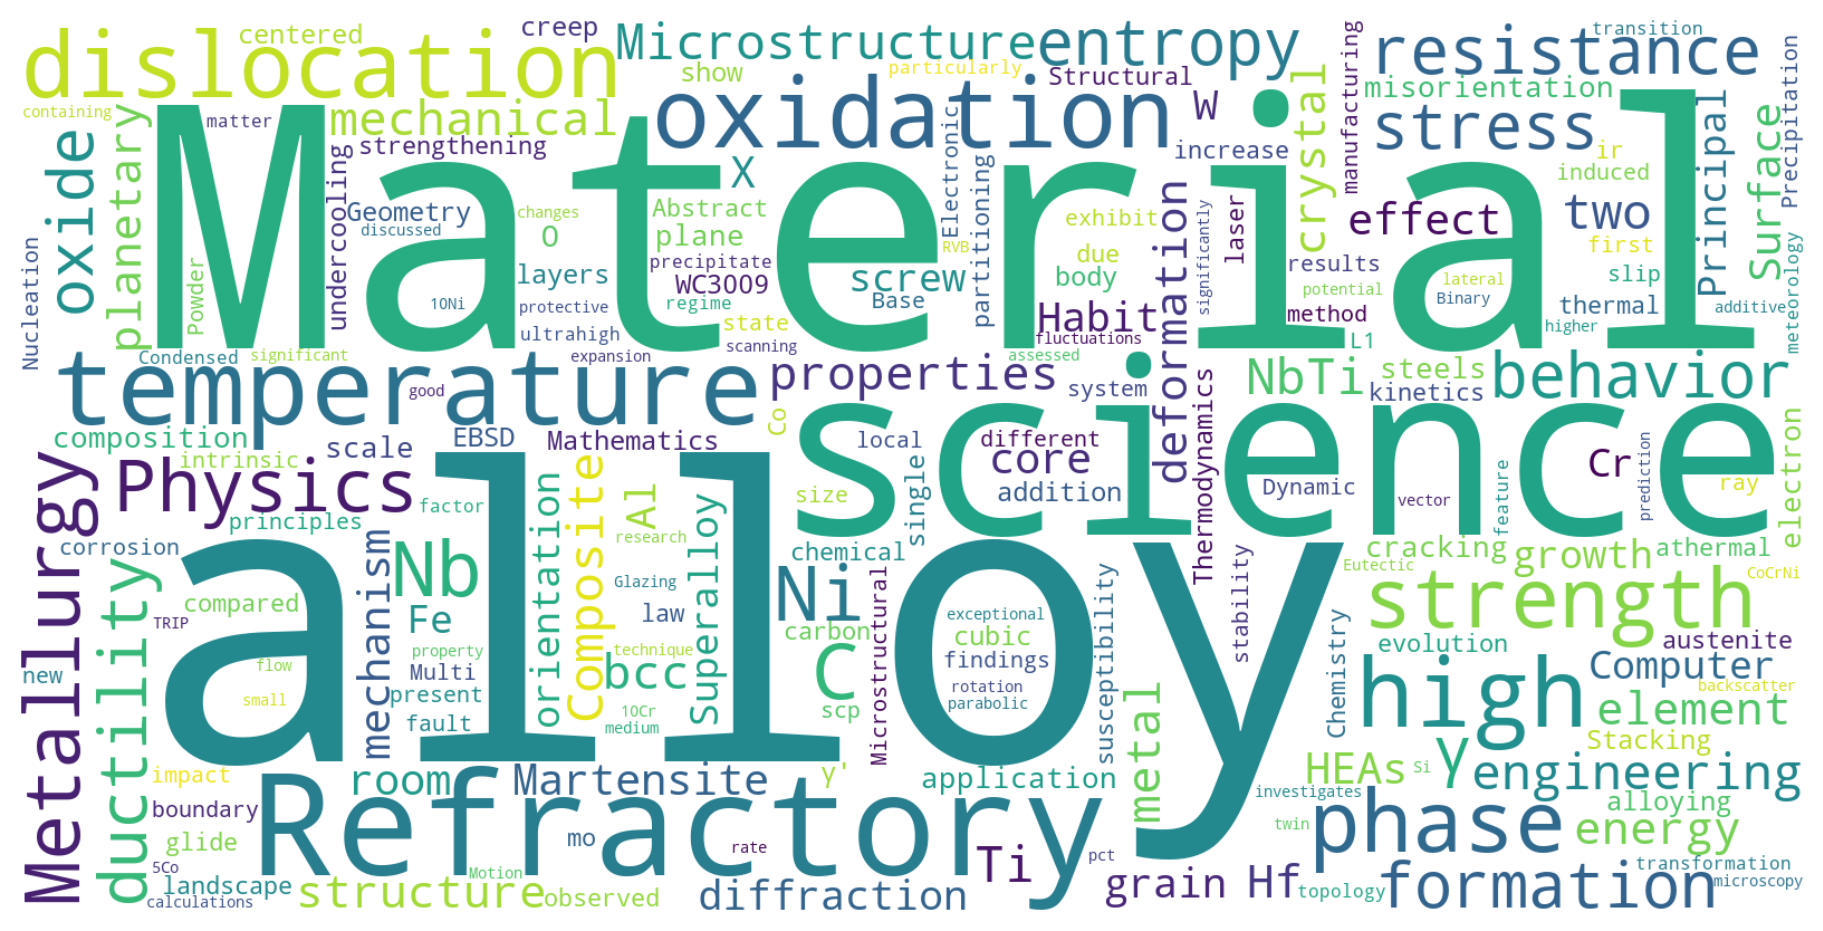

In [10]:
#| echo: false
#| output: true

plt.figure(figsize=(12, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

## Who is citing CARD lab research

In [11]:
#| echo: false
#| output: false

from pathlib import Path
from urllib.parse import quote

import pandas as pd
import plotly.express as px
import requests

CITING_REFS_PATH = Path("../files/references_citing_us.csv")
USER_AGENT = "CARD Lab scientometrics (mailto:paytonej@ucmail.uc.edu)"
TOP_N_JOURNALS = 15


def _normalize_doi_for_journal_chart(value):
    if pd.isna(value):
        return None
    doi = str(value).strip().lower()
    doi = doi.replace("https://doi.org/", "").replace("http://doi.org/", "")
    return doi or None


def _fetch_openalex_journal_name(doi, session):
    work_url = f"https://api.openalex.org/works/https://doi.org/{quote(doi, safe='')}"
    headers = {"User-Agent": USER_AGENT}
    try:
        response = session.get(work_url, headers=headers, timeout=30)
        response.raise_for_status()
        work = response.json()
    except Exception:
        return None

    primary_location = work.get("primary_location") or {}
    source = primary_location.get("source") or {}
    journal_name = str(source.get("display_name") or "").strip()
    return journal_name or None


fig_journals = None

if not CITING_REFS_PATH.exists():
    print(f"Warning: {CITING_REFS_PATH} not found.")
else:
    df_refs = pd.read_csv(CITING_REFS_PATH)
    if "citing_doi" not in df_refs.columns:
        print("Warning: citing_doi column missing in references_citing_us.csv.")
    else:
        if "citing_journal_name" not in df_refs.columns:
            df_refs["citing_journal_name"] = pd.NA

        df_refs["citing_doi_norm"] = df_refs["citing_doi"].apply(_normalize_doi_for_journal_chart)

        existing_map = (
            df_refs[["citing_doi_norm", "citing_journal_name"]]
            .dropna(subset=["citing_doi_norm"])
            .assign(citing_journal_name=lambda d: d["citing_journal_name"].fillna("").astype(str).str.strip())
        )
        existing_map = existing_map[existing_map["citing_journal_name"] != ""]
        journal_cache = {}
        if not existing_map.empty:
            journal_cache.update(
                dict(zip(existing_map["citing_doi_norm"], existing_map["citing_journal_name"]))
            )

        pending_dois = sorted(
            doi
            for doi in df_refs["citing_doi_norm"].dropna().unique().tolist()
            if doi not in journal_cache
        )

        if pending_dois:
            print(f"Fetching journal names for {len(pending_dois)} citing DOI(s)...")
            session = requests.Session()
            for idx, doi in enumerate(pending_dois, start=1):
                journal_name = _fetch_openalex_journal_name(doi, session)
                if journal_name:
                    journal_cache[doi] = journal_name
                if idx % 25 == 0:
                    print(f"  Journal fetch progress: {idx}/{len(pending_dois)}")

        if journal_cache:
            df_refs["citing_journal_name"] = df_refs["citing_doi_norm"].map(journal_cache)
            df_refs.to_csv(CITING_REFS_PATH, index=False)

        df_dois = (
            df_refs[["citing_doi_norm", "citing_journal_name"]]
            .drop_duplicates(subset=["citing_doi_norm"])
            .dropna(subset=["citing_doi_norm"])
            .copy()
        )
        df_dois["citing_journal_name"] = df_dois["citing_journal_name"].fillna("").astype(str).str.strip()
        df_dois = df_dois[df_dois["citing_journal_name"] != ""].copy()

        if df_dois.empty:
            print("Warning: no journal data available after metadata lookup.")
        else:
            journal_counts = (
                df_dois.groupby("citing_journal_name")["citing_doi_norm"]
                .nunique()
                .rename("citations")
                .reset_index()
                .rename(columns={"citing_journal_name": "journal_name"})
            )

            impact_cache = {}
            if {"citing_journal_name", "citing_impact_factor"}.issubset(df_refs.columns):
                impact_source = (
                    df_refs[["citing_journal_name", "citing_impact_factor"]]
                    .dropna(subset=["citing_journal_name"])
                    .assign(
                        citing_journal_name=lambda d: d["citing_journal_name"].fillna("").astype(str).str.strip(),
                        citing_impact_factor=lambda d: pd.to_numeric(d["citing_impact_factor"], errors="coerce"),
                    )
                )
                impact_source = impact_source[impact_source["citing_journal_name"] != ""]
                impact_source = impact_source.dropna(subset=["citing_impact_factor"]).drop_duplicates(
                    subset=["citing_journal_name"], keep="last"
                )
                impact_cache = dict(
                    zip(impact_source["citing_journal_name"], impact_source["citing_impact_factor"])
                )

            journal_counts["impact_factor"] = journal_counts["journal_name"].map(impact_cache)
            journal_counts["impact_factor"] = pd.to_numeric(
                journal_counts["impact_factor"], errors="coerce"
            ).fillna(-1.0)
            journal_counts = journal_counts.sort_values(
                by=["citations", "impact_factor", "journal_name"],
                ascending=[False, False, True],
            ).head(TOP_N_JOURNALS)

            fig_journals = px.bar(
                journal_counts,
                x="journal_name",
                y="citations",
                hover_data={"impact_factor": True},
                title="Top 15 Journals Citing CARD Lab Work Products",
                labels={
                    "journal_name": "Journal",
                    "citations": "Unique citing papers",
                    "impact_factor": "OpenAlex 2yr mean citedness",
                },
            )
            fig_journals.update_layout(height=520, xaxis_tickangle=-45)

Fetching journal names for 26 citing DOI(s)...


  Journal fetch progress: 25/26


In [12]:
#| echo: false
#| output: true

if fig_journals is not None:
    fig_journals.show()
else:
    print("Warning: journal figure was not generated.")


In [13]:
#| echo: false
#| output: false

from pathlib import Path
from urllib.parse import quote

import pandas as pd
import plotly.graph_objects as go
import requests

CITING_REFS_PATH = Path("../files/references_citing_us.csv")
OPENALEX_USER_AGENT = "CARD Lab scientometrics (mailto:paytonej@ucmail.uc.edu)"
EXCLUDED_AFFILIATION_TOKEN = "university of cincinnati"


def _normalize_doi_for_subplots(value):
    if pd.isna(value):
        return None
    doi = str(value).strip().lower()
    doi = doi.replace("https://doi.org/", "").replace("http://doi.org/", "")
    return doi or None


def _short_label(text, max_len=40):
    text = str(text or "").strip()
    if len(text) <= max_len:
        return text
    return text[: max_len - 1].rstrip() + "..."


def _fetch_openalex_affiliation_data(doi, session):
    work_url = f"https://api.openalex.org/works/https://doi.org/{quote(doi, safe='')}"
    headers = {"User-Agent": OPENALEX_USER_AGENT}
    try:
        response = session.get(work_url, headers=headers, timeout=30)
        response.raise_for_status()
        work = response.json()
    except Exception:
        return {"citing_affiliations": "", "citing_affiliation_countries": ""}

    affiliations = []
    countries = []
    for authorship in work.get("authorships", []) or []:
        for inst in authorship.get("institutions", []) or []:
            name = str(inst.get("display_name") or "").strip()
            country_code = str(inst.get("country_code") or "").strip()
            if name:
                affiliations.append(name)
            if country_code:
                countries.append(country_code)

    unique_affiliations = sorted(dict.fromkeys(affiliations))
    unique_countries = sorted(dict.fromkeys(countries))
    return {
        "citing_affiliations": "; ".join(unique_affiliations),
        "citing_affiliation_countries": "; ".join(unique_countries),
    }


fig_country = None
fig_affiliations = None

if not CITING_REFS_PATH.exists():
    print(f"Warning: {CITING_REFS_PATH} not found.")
else:
    df_refs = pd.read_csv(CITING_REFS_PATH)
    required_cols = {"citing_doi", "citing_affiliation_countries", "citing_affiliations"}
    if "citing_doi" not in df_refs.columns:
        print("Warning: citing_doi column missing in references_citing_us.csv.")
    else:
        for col in ["citing_affiliation_countries", "citing_affiliations"]:
            if col not in df_refs.columns:
                df_refs[col] = ""

        df_refs["citing_doi_norm"] = df_refs["citing_doi"].apply(_normalize_doi_for_subplots)

        # If affiliation fields are empty, backfill from OpenAlex authorship institutions.
        aff_nonempty = df_refs["citing_affiliations"].fillna("").astype(str).str.strip().ne("").sum()
        country_nonempty = df_refs["citing_affiliation_countries"].fillna("").astype(str).str.strip().ne("").sum()

        if aff_nonempty == 0 or country_nonempty == 0:
            # Identify DOIs with existing affiliation data
            known_aff = (
                df_refs[["citing_doi_norm", "citing_affiliations", "citing_affiliation_countries"]]
                .dropna(subset=["citing_doi_norm"])
                .copy()
            )
            known_aff["citing_affiliations"] = known_aff["citing_affiliations"].fillna("").astype(str).str.strip()
            known_aff["citing_affiliation_countries"] = known_aff["citing_affiliation_countries"].fillna("").astype(str).str.strip()
            known_aff = known_aff[
                (known_aff["citing_affiliations"] != "") | (known_aff["citing_affiliation_countries"] != "")
            ]
            known_dois = set(known_aff["citing_doi_norm"].unique())

            pending_dois = sorted(
                doi
                for doi in df_refs["citing_doi_norm"].dropna().unique().tolist()
                if doi not in known_dois
            )

            if pending_dois:
                print(f"Fetching affiliation metadata for {len(pending_dois)} citing DOI(s)...")
                session = requests.Session()
                affiliation_data = {}
                for idx, doi in enumerate(pending_dois, start=1):
                    affiliation_data[doi] = _fetch_openalex_affiliation_data(doi, session)
                    if idx % 25 == 0:
                        print(f"  Affiliation fetch progress: {idx}/{len(pending_dois)}")

                # Update df_refs directly with fetched affiliation data
                for doi, data in affiliation_data.items():
                    mask = df_refs["citing_doi_norm"] == doi
                    df_refs.loc[mask, "citing_affiliations"] = data.get("citing_affiliations", "")
                    df_refs.loc[mask, "citing_affiliation_countries"] = data.get("citing_affiliation_countries", "")

                # Save updated data directly to references_citing_us.csv
                df_refs.drop(columns=["citing_doi_norm"], inplace=True)
                df_refs.to_csv(CITING_REFS_PATH, index=False)
                print(f"Updated {CITING_REFS_PATH} with affiliation data.")

        if not required_cols.issubset(df_refs.columns):
            print(
                "Warning: missing geocoding columns in references_citing_us.csv. "
                "Run the geocoding/enrichment cell before this plot cell."
            )
        else:
            df_dois = (
                df_refs[["citing_doi", "citing_affiliation_countries", "citing_affiliations"]]
                .drop_duplicates(subset=["citing_doi"])
                .copy()
            )
            df_dois["citing_doi"] = df_dois["citing_doi"].apply(_normalize_doi_for_subplots)
            df_dois = df_dois[df_dois["citing_doi"].notna()].copy()

            uc_mask = (
                df_dois["citing_affiliations"].fillna("").str.lower().str.contains(EXCLUDED_AFFILIATION_TOKEN, na=False)
            )
            excluded_dois = set(df_dois.loc[uc_mask, "citing_doi"] )
            if excluded_dois:
                df_dois = df_dois[~df_dois["citing_doi"].isin(excluded_dois)].copy()

            df_countries = (
                df_dois.assign(country=df_dois["citing_affiliation_countries"].fillna("").astype(str).str.split("; "))
                .explode("country")
            )
            df_countries["country"] = df_countries["country"].str.strip()
            df_countries = df_countries[df_countries["country"].notna() & (df_countries["country"] != "")].copy()
            country_counts = df_countries.groupby("country")["citing_doi"].nunique().sort_values(ascending=False)

            df_affiliations = (
                df_dois.assign(affiliation=df_dois["citing_affiliations"].fillna("").astype(str).str.split("; "))
                .explode("affiliation")
            )
            df_affiliations["affiliation"] = df_affiliations["affiliation"].str.strip()
            df_affiliations = df_affiliations[df_affiliations["affiliation"].notna() & (df_affiliations["affiliation"] != "")].copy()
            top_affiliations = df_affiliations.groupby("affiliation")["citing_doi"].nunique().sort_values(ascending=False).head(10)

            if not country_counts.empty:
                fig_country = go.Figure(data=[go.Pie(labels=country_counts.index.tolist(), values=country_counts.values.tolist(), hole=0.35, sort=True)])
                fig_country.update_layout(title="CARD Lab Work Citations by Country of Researcher Affiliation", height=520, margin=dict(l=40, r=30, t=80, b=30))

            if not top_affiliations.empty:
                top_affiliations_for_plot = top_affiliations.sort_values(ascending=True)
                short_labels = [_short_label(name, max_len=40) for name in top_affiliations_for_plot.index.tolist()]
                fig_affiliations = go.Figure(data=[go.Bar(x=top_affiliations_for_plot.values.tolist(), y=short_labels, orientation="h", customdata=top_affiliations_for_plot.index.tolist(), hovertemplate="%{customdata}<br>Citations: %{x}<extra></extra>")])
                fig_affiliations.update_layout(title="Top 10 Citing Affiliations", xaxis_title="Unique citing papers", yaxis_title="Affiliation", height=620, margin=dict(l=180, r=30, t=80, b=40))
                fig_affiliations.update_xaxes(tickmode="linear", dtick=1, rangemode="tozero")
                fig_affiliations.update_yaxes(automargin=True)

            if fig_country is None and fig_affiliations is None:
                print("Warning: no country/affiliation data available to plot.")

Fetching affiliation metadata for 26 citing DOI(s)...


  Affiliation fetch progress: 25/26
Updated ../files/references_citing_us.csv with affiliation data.


/var/folders/nz/l5ynytfs6sj2drjd5cs1wckc0000gn/T/ipykernel_92409/296093338.py:110: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Northwestern Polytechnical University' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.

/var/folders/nz/l5ynytfs6sj2drjd5cs1wckc0000gn/T/ipykernel_92409/296093338.py:111: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'CN' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.



In [14]:
#| echo: false
#| output: true

if fig_country is not None:
    fig_country.show()
else:
    print("Warning: country figure was not generated.")

if fig_affiliations is not None:
    fig_affiliations.show()
else:
    print("Warning: affiliation figure was not generated.")


```{=html}
<a href="../files/references_citing_us_map.html" target="_blank">View full screen</a>
<div style="width: 100%;">
  <iframe src="../files/references_citing_us_map.html" style="width: 100%; height: 700px; border: 0;"></iframe>
</div>
```
::: {style="font-size: 0.75rem;"}
Created from the [CARD Lab Zotero export](https://card-lab.github.io/files/files/zotero_group_library.json) using OpenCitations/Crossref data. Inspired by Chen Liu's [`citation_map`](https://github.com/ChenLiu-1996/CitationMap) tool.
:::